Import Statements

In [24]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt

Small Data Manipulation

In [25]:
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    macd_hist = macd_line - signal_line
    return macd_hist.fillna(0)  # Return MACD histogram

# === 1. LOAD & ENHANCE DATA ===
def load_your_data(path):
    df = pd.read_csv(path, parse_dates=['Datetime'], index_col='Datetime')
    df['Return'] = df['Close'].pct_change()
    df['SMA_5'] = df['Close'].rolling(5).mean()
    df['SMA_20'] = df['Close'].rolling(20).mean()
    df['Volatility'] = df['Return'].rolling(10).std()
    df['Momentum'] = df['Close'] - df['Close'].shift(10)
    df['RSI_14'] = compute_rsi(df['Close'], period=14)
    df['Momentum_5'] = df['Close'] - df['Close'].shift(5)
    df = df.dropna()
    return df

# === 2. PREPROCESS DATA ===
def preprocess_data(df, sequence_length=30):
    features = ['Close', 'SMA_5', 'SMA_20', 'Volatility', 'Momentum']
    scaler = MinMaxScaler()
    data = scaler.fit_transform(df[features])
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i])
        # Simple label: 0 = sell, 1 = hold, 2 = buy
        future_return = df['Close'].iloc[i+1] - df['Close'].iloc[i] if i+1 < len(df) else 0
        if future_return > 0.5:
            y.append(2)  # Buy
        elif future_return < -0.5:
            y.append(0)  # Sell
        else:
            y.append(1)  # Hold
    return np.array(X), np.array(y)

# Removing NaN values
def clean_data(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.ffill().bfill()

    for col in df.select_dtypes(include=np.number):
        q1 = df[col].quantile(0.01)
        q99 = df[col].quantile(0.99)
        df[col] = df[col].clip(q1, q99)
    assert not df.isnull().any().any(), "NaN values still present after cleaning"
    return df


def create_sequences(data, labels, seq_length):
    X_seqs, y_seqs = [], []
    for i in range(seq_length, len(data)):
        X_seqs.append(data[i - seq_length:i])
        y_seqs.append(labels[i])
    return torch.FloatTensor(X_seqs), torch.LongTensor(y_seqs)


df = load_your_data('allStock_data.csv')
df = clean_data(df)
print(df)

                         Open      High       Low     Close     Volume Ticker  \
Datetime                                                                        
2025-03-17 17:00:00  604.3100  609.5460  562.5385  604.2600   524850.0   META   
2025-03-17 17:00:00   60.4476   60.6660   60.4217   60.4217      446.0   CSCO   
2025-03-17 17:00:00  237.2000  391.0340  195.4941  237.1300   284585.0   TSLA   
2025-03-17 17:00:00  104.8350  111.3073   97.5796  104.9650    44201.0    AMD   
2025-03-17 17:00:00  398.6400  416.0327  397.5400  399.0000     1110.0   ADBE   
...                       ...       ...       ...       ...        ...    ...   
2025-04-10 19:00:00  382.0200  383.4800  377.4500  380.0000    72151.0   MSFT   
2025-04-10 19:00:00   88.8200   88.9000   85.6700   88.0337    62420.0    AMD   
2025-04-10 19:00:00  191.0000  191.2000  189.0000  189.2000   153517.0   AAPL   
2025-04-10 19:00:00  255.1200  258.2400  248.9500  253.0300  1235916.0    CRM   
2025-04-10 19:00:00  133.350

Model

In [26]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, num_classes=3):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # Last time step
        return out


Model Training

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

def train_lstm_model(df, feature_columns, target_column='Returns', seq_length=10, epochs=30, batch_size=64, learning_rate=1e-3, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Train an LSTM model on financial time series data (single-ticker version).
    """
    
    trainingLoss = []
    valueAccuracy = []
    
    # Sort by datetime only
    df = df.sort_index()

    # Normalize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[feature_columns])
    y = df[target_column].values

    # Convert regression target into 3-class classification
    y_class = np.digitize(y, bins=[-0.001, 0.001])  # 0: down, 1: neutral, 2: up

    X_all = []
    y_all = []
    for i in range(seq_length, len(X_scaled)):
        X_all.append(X_scaled[i - seq_length:i])
        y_all.append(y_class[i])

    X_all = np.array(X_all)
    y_all = np.array(y_all)

    # Split into train/test
    X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

    # Convert to PyTorch tensors
    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.long).to(device)
    X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test = torch.tensor(y_test, dtype=torch.long).to(device)

    # Define model, loss, optimizer
    input_size = X_train.shape[2]
    model = LSTMModel(input_size=input_size).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training loop
    for epoch in range(epochs):
        model.train()
        epochLoss = 0
        permutation = torch.randperm(X_train.size(0))
        
        
        for i in range(0, X_train.size(0), batch_size):
            indices = permutation[i:i+batch_size]
            batch_x, batch_y = X_train[indices], y_train[indices]

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            epochLoss += loss.item()
        
        trainingLoss.append(epochLoss / (X_train.size(0) // batch_size))

        # Evaluation
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            predictions = torch.argmax(test_outputs, dim=1)
            acc = (predictions == y_test).float().mean().item()
            valueAccuracy.append(acc)
        print(f"Epoch {epoch+1}/{epochs} - Test Accuracy: {acc:.4f}")


    return model, X_test, y_test, test_dates, trainingLoss, valueAccuracy  # ensure all 6 are returned




def load_your_data(path):
    df = pd.read_csv(path, parse_dates=['Datetime'], index_col='Datetime')
    df['Return'] = df['Close'].pct_change()
    df['SMA_5'] = df['Close'].rolling(5).mean()
    df['SMA_20'] = df['Close'].rolling(20).mean()
    df['Volatility'] = df['Return'].rolling(10).std()
    df['Momentum'] = df['Close'] - df['Close'].shift(10)
    df['RSI_14'] = compute_rsi(df['Close'], period=14)
    df['Momentum_5'] = df['Close'] - df['Close'].shift(5)
    df = df.dropna()
    return df

df = load_your_data('allStock_data.csv')
df = df.dropna()  # or custom cleaning
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Volatility', 'Momentum_5', 'RSI_14', 'MACD']


model, X_test, y_test, test_dates, train_losses, val_accuracies = train_lstm_model(df, features)

Epoch 1/30 - Test Accuracy: 0.4305
Epoch 2/30 - Test Accuracy: 0.4294
Epoch 3/30 - Test Accuracy: 0.4237
Epoch 4/30 - Test Accuracy: 0.4294
Epoch 5/30 - Test Accuracy: 0.4282
Epoch 6/30 - Test Accuracy: 0.4351
Epoch 7/30 - Test Accuracy: 0.4363
Epoch 8/30 - Test Accuracy: 0.4363
Epoch 9/30 - Test Accuracy: 0.4351
Epoch 10/30 - Test Accuracy: 0.4397
Epoch 11/30 - Test Accuracy: 0.4374
Epoch 12/30 - Test Accuracy: 0.4524
Epoch 13/30 - Test Accuracy: 0.4581
Epoch 14/30 - Test Accuracy: 0.4546
Epoch 15/30 - Test Accuracy: 0.4719
Epoch 16/30 - Test Accuracy: 0.4501
Epoch 17/30 - Test Accuracy: 0.4638
Epoch 18/30 - Test Accuracy: 0.4569
Epoch 19/30 - Test Accuracy: 0.4558
Epoch 20/30 - Test Accuracy: 0.4524
Epoch 21/30 - Test Accuracy: 0.4719
Epoch 22/30 - Test Accuracy: 0.4638
Epoch 23/30 - Test Accuracy: 0.4661
Epoch 24/30 - Test Accuracy: 0.4856
Epoch 25/30 - Test Accuracy: 0.4627
Epoch 26/30 - Test Accuracy: 0.4569
Epoch 27/30 - Test Accuracy: 0.4765
Epoch 28/30 - Test Accuracy: 0.4604
E

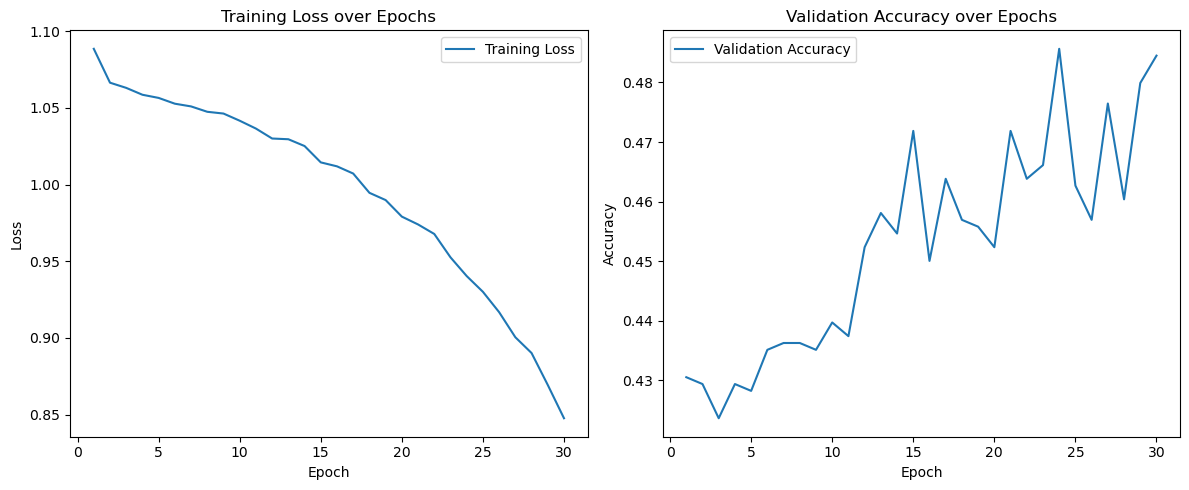

In [32]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy over Epochs")
plt.legend()

plt.tight_layout()
plt.show()


Backtesting

In [ ]:
import torch
import numpy as np
import pandas as pd
import vectorbt as vbt

# 1. Predict with trained model
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    predictions = torch.argmax(outputs, dim=1).cpu().numpy()

# 2. Map predictions to trading signals
# 2 = up → 1 (buy), 1 = neutral/down → 0 (hold)
signals = np.where(predictions == 2, 1, 0)

# 3. Align with dates and prices
# Ensure test_dates is a pandas DatetimeIndex
if not isinstance(test_dates, pd.DatetimeIndex):
    test_dates = pd.to_datetime(test_dates)

# Get close prices for the same period
close_prices = df.loc[test_dates, 'Close']

# Ensure the signal length matches
signals_series = pd.Series(signals, index=test_dates).reindex(close_prices.index).fillna(0)

# 4. Run vectorbt backtest
portfolio = vbt.Portfolio.from_signals(
    close=close_prices,
    entries=signals_series == 1,
    exits=signals_series.shift(1) == 1,  # Exit after 1 bar
    direction='longonly',
    freq='1D'  # Adjust if intraday
)

# 5. Show performance
print(portfolio.stats())
portfolio.plot().show()
